# Project 1 - Height Prediction using Simple Linear Regression.
- In this project we build a ML model to predict the height feature. 

## Steps:
1. Divide the features based on dependent and independent features.
2. Train test split the dataset
3. Standardize the dataset, by using fit_transform() and transform() on training data and test data (of independent feature) respectively.
4. Train the model using Linear Regression.
    - object.fit(X_train, y_train)
5. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("../../Datasets/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Height vs Weight')

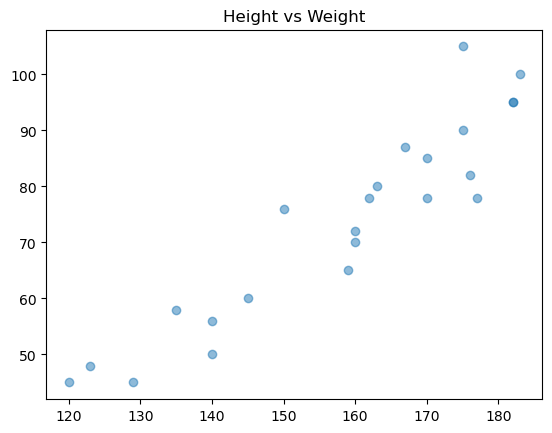

In [3]:
plt.scatter(df['Height'], df['Weight'], alpha=0.5)
plt.title('Height vs Weight')

--> This shows that the datapoints follow a linear relation.

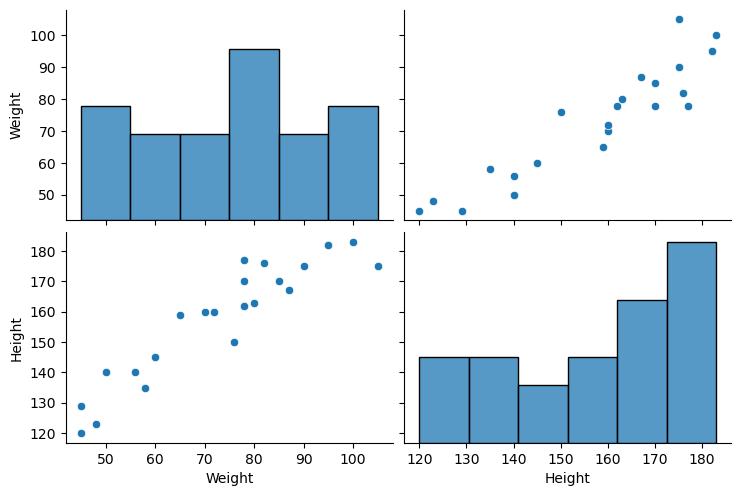

In [4]:
sns.pairplot(df, aspect=1.5)

In [5]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


<Axes: >

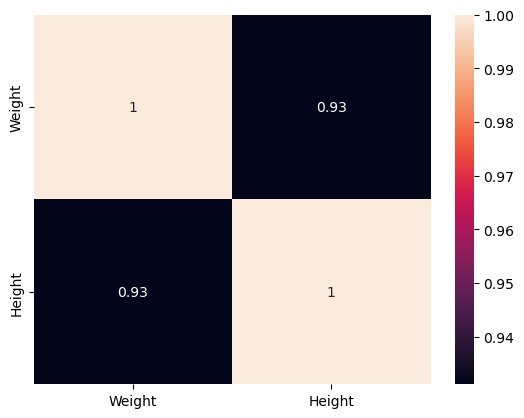

In [6]:
sns.heatmap(df.corr(), annot=True)

In [7]:
X = df[["Weight"]]
y = df["Height"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=55)


In [9]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16, 1), (7, 1), (16,), (7,))

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [11]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression(n_jobs=-1)


In [13]:
model.fit(X_train, y_train)


LinearRegression(n_jobs=-1)

In [15]:
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [15.81259339]
Model Intercept: 159.25


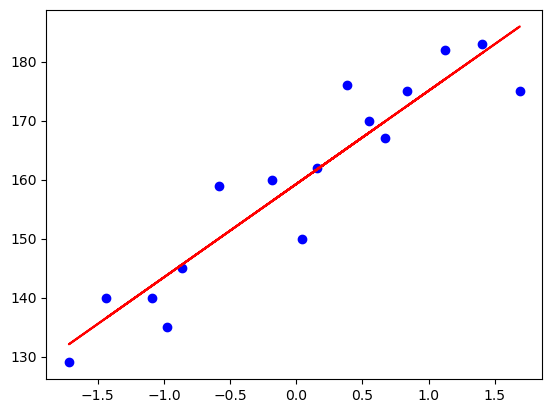

In [22]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, model.predict(X_train), color='r')
# plt.plot(y_test, y_pred, color='r', label='Test Data')


In [28]:
y_pred_test = model.predict(X_test)

Text(0.5, 1.0, 'Test Data: Height vs Weight')

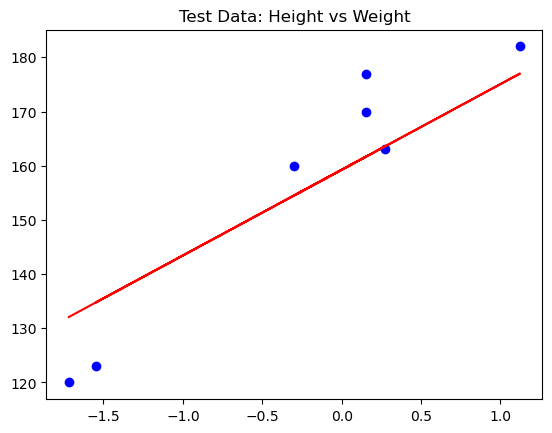

In [32]:
plt.scatter(X_test, y_test, color='blue')
plt.plot(X_test, model.predict(X_test), color='r')
plt.title('Test Data: Height vs Weight')

In [33]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred_test)
print("Mean Squared Error:", mse)
mae = mean_absolute_error(y_test, y_pred_test)
print("Mean Absolute Error:", mae)
r2 = r2_score(y_test, y_pred_test)
print("R-squared:", r2)


Mean Squared Error: 91.73439079172933
Mean Absolute Error: 8.345739626227425
R-squared: 0.8292957181833991


## Asumptions


### 1. Plot a Scatter plot for the prediction.

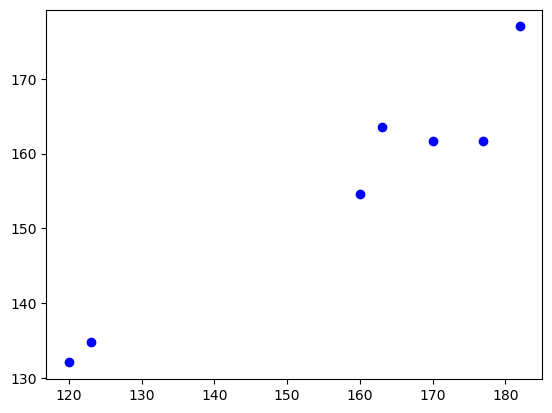

In [35]:
plt.scatter(y_test, y_pred_test,  color='blue')

- This shows a linear distribution, hence the model has done very good predictions.

### 2. Residuals

C:\Users\OM MAKWANA\AppData\Local\Temp\ipykernel_21416\4272554824.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

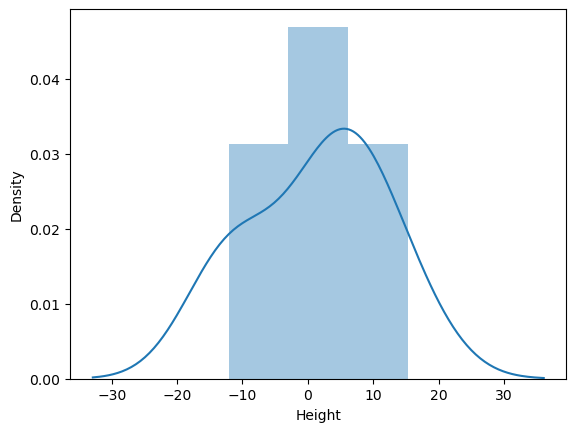

In [38]:
residuals = y_test - y_pred_test

sns.distplot(residuals, kde=True)

- We are getting a kind of normal distribution, so i can conclude that the model created is a better model.

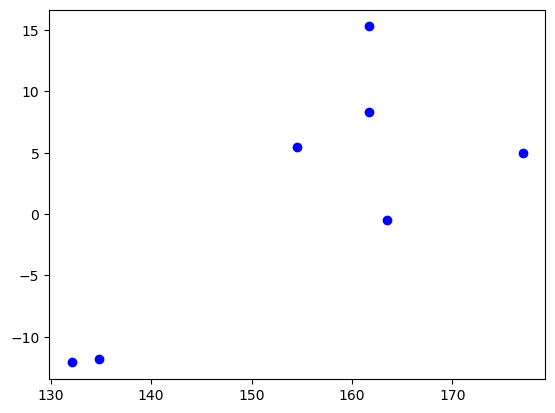

In [39]:
plt.scatter(y_pred_test, residuals, color='blue')

- Since the predicted data shows uniform distribution, this is a very good model.